# Analysis of model results

## Imports

In [1]:
import arviz as az
import bambi as bmb
import polars as  pl
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from kidney.paths import RESULTS_DIR, PREPARED_FILES, PLOT_DIR
from kidney.plotting import forestplot_oz, plot_ppc
from kidney.sign_probs import get_sign_probs, get_signif

In [2]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

## Configuration

In [3]:
az.rcParams["data.load"] = "eager"

## Power analysis

In [4]:
idata_power = az.from_netcdf(RESULTS_DIR / "idata_power.nc")
idata_power_baseline = az.from_netcdf(RESULTS_DIR / "idata_power_baseline.nc")
idata_power

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [5]:
print("Power:")
display(az.summary(idata_power, var_names=["~mu", "~1|rat"]))
print("Power baseline:")
display(az.summary(idata_power_baseline, var_names=["~mu", "~1|rat"]))

Power:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.439,0.012,0.417,0.462,0.000,0.000,2693.0,2467.0,1.00
Intercept,-0.656,0.169,-0.966,-0.339,0.005,0.004,992.0,1649.0,1.01
gtyp[fa/fa],0.171,0.253,-0.314,0.620,0.008,0.006,1050.0,1382.0,1.00
age[Young],-0.059,0.255,-0.507,0.423,0.007,0.005,1326.0,1582.0,1.00
sex[M],-0.533,0.243,-0.983,-0.070,0.006,0.005,1422.0,1766.0,1.00
"gtyp:age[fa/fa, Young]",0.124,0.354,-0.521,0.802,0.010,0.008,1164.0,1457.0,1.00
"gtyp:sex[fa/fa, M]",0.494,0.343,-0.188,1.120,0.009,0.008,1347.0,1564.0,1.00
1|rat_sigma,0.469,0.071,0.351,0.605,0.002,0.001,1037.0,1717.0,1.00


Power baseline:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.548,0.015,0.521,0.576,0.000,0.000,2522.0,2208.0,1.0
Intercept,2.939,0.229,2.516,3.367,0.007,0.005,927.0,1450.0,1.0
gtyp[fa/fa],-0.384,0.335,-0.986,0.255,0.010,0.007,1027.0,1603.0,1.0
age[Young],-0.444,0.335,-1.061,0.216,0.009,0.007,1302.0,1635.0,1.0
sex[M],-0.330,0.311,-0.900,0.251,0.010,0.006,1006.0,1617.0,1.0
"gtyp:age[fa/fa, Young]",0.470,0.463,-0.399,1.345,0.013,0.010,1247.0,1605.0,1.0
"gtyp:sex[fa/fa, M]",-0.377,0.427,-1.178,0.392,0.015,0.008,855.0,1502.0,1.0
1|rat_sigma,0.613,0.092,0.460,0.788,0.003,0.002,941.0,1499.0,1.0


# Compute group values

In [6]:
t_groups_change, t_groups_bsl = (
    {
        "fa/+:female:adult":   idata.posterior["Intercept"],
        "fa/+:female:young":   idata.posterior["Intercept"] + idata.posterior["age"],
        "fa/+:male:adult":     idata.posterior["Intercept"] + idata.posterior["sex"],
        "fa/+:male:young":     idata.posterior["Intercept"] + idata.posterior["sex"] + idata.posterior["age"],
        "fa/fa:female:adult":  idata.posterior["Intercept"] + idata.posterior["gtyp"],
        "fa/fa:female:young":  idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["age"] + idata.posterior["gtyp:age"],
        "fa/fa:male:adult":    idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["sex"] + idata.posterior["gtyp:sex"],
        "fa/fa:male:young":    idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["sex"] + idata.posterior["gtyp:sex"] + idata.posterior["age"] + idata.posterior["gtyp:age"],
    }
    for idata in (idata_power, idata_power_baseline)
)

In [7]:
ts_change, ts_vehicle = (
    {
    "fa/fa adult M":   t_groups["fa/fa:male:adult"],
    "fa/fa young M":   t_groups["fa/fa:male:young"],
    "fa/+ adult M":    t_groups["fa/+:male:adult"],
    "fa/+ young M":    t_groups["fa/+:male:young"],
    "fa/fa adult F":   t_groups["fa/fa:female:adult"],
    "fa/fa young F":   t_groups["fa/fa:female:young"],
    "fa/+ adult F":    t_groups["fa/+:female:adult"],
    "fa/+ young F":    t_groups["fa/+:female:young"],
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_change = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
})

print("Change sign probabilities:")
display(get_sign_probs(ts_change))

Change sign probabilities:


{'fa/fa adult M': 0.0095,
 'fa/fa young M': 0.0165,
 'fa/+ adult M': 0.0,
 'fa/+ young M': 0.0,
 'fa/fa adult F': 0.00675,
 'fa/fa young F': 0.0255,
 'fa/+ adult F': 0.00075,
 'fa/+ young F': 0.00375}

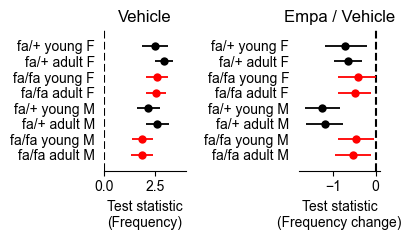

In [8]:
f, axes = plt.subplots(1, 2, figsize=(4, 2.5))
axes[1] = forestplot_oz(axes[1], ts_change);
axes[1].set_title("Empa / Vehicle");

axes[0] = forestplot_oz(axes[0], ts_vehicle);
axes[0].set_title("Vehicle");

for ax in axes:
    ax.spines[['top', 'right', 'left']].set_visible(False)
axes[1].set_xlabel('Test statistic\n(Frequency change)')
axes[0].set_xlabel('Test statistic\n(Frequency)')

axes[0].set_xlim(0.0, 4)
axes[1].set_xlim(-1.8, 0.1)

f.tight_layout()
# f.savefig(PLOT_DIR / "ts_power_groups.pdf", bbox_inches="tight")

## TS representing difference between fa/fa and fa/+

In [9]:
ts_change, ts_vehicle = (
    {
        "M adult":   t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"],
        "M young":   t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"],
        "F adult": t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"],
        "F young": t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"],        
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_gtyp = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_change))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'M adult': 0.9825, 'M young': 0.99325, 'F adult': 0.75225, 'F young': 0.80975}


Vehicle sign probabilities:


{'M adult': 0.02725, 'M young': 0.2135, 'F adult': 0.118, 'F young': 0.582}

[]

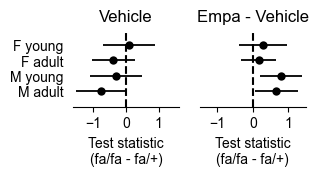

In [10]:
f, axes = plt.subplots(1, 2, figsize=(3, 1))
plt.subplots_adjust(wspace=0.2)

for ax, ts_, tle in zip(axes, (ts_vehicle, ts_change), ('Vehicle', 'Empa - Vehicle')):
    ax = forestplot_oz(ax, ts_);
    ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Test statistic\n(fa/fa - fa/+)')

axes[1].set_yticks([],[])
# f.savefig(PLOT_DIR / "ts_pow_CompareGtypForAgesSexes.pdf", bbox_inches="tight")

## TS representing difference between young and adult

In [11]:
ts_change, ts_vehicle = (
    {
        "fa/fa":   t_groups["fa/fa:male:young"] - t_groups["fa/fa:male:adult"],
        "fa/+":   t_groups["fa/+:male:young"] - t_groups["fa/+:male:adult"],
        # "F fa/fa":  t_groups["fa/fa:female:young"] - t_groups["fa/fa:female:adult"],
        # "F fa/+":   t_groups["fa/+:female:young"] - t_groups["fa/+:female:adult"],
        # "fa/fa": (t_groups["fa/fa:female:young"] - t_groups["fa/fa:female:adult"] + t_groups["fa/fa:male:young"] - t_groups["fa/fa:male:adult"])/2,
        # "fa/+": (t_groups["fa/+:female:young"] - t_groups["fa/+:female:adult"] + t_groups["fa/+:male:young"] - t_groups["fa/+:male:adult"])/2,
        # "overall": (t_groups["fa/fa:young"]+t_groups["fa/fa:old"])/2 - (t_groups["fa/+:young"]+t_groups["fa/+:old"])/2,
        
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_age = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_change))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'fa/fa': 0.60475, 'fa/+': 0.41}


Vehicle sign probabilities:


{'fa/fa': 0.5395, 'fa/+': 0.09275}

[]

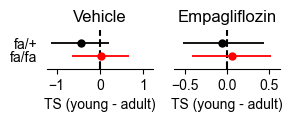

In [12]:
f, axes = plt.subplots(1, 2, figsize=(3, 0.5))
plt.subplots_adjust(wspace=0.2)

for ax, ts_, tle in zip(axes, (ts_vehicle, ts_change), ('Vehicle', 'Empagliflozin')):
    ax = forestplot_oz(ax, ts_);
    ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('TS (young - adult)')
    
# axes[0].set_xlim(-0.01,0.01)
# axes[1].set_xlim(-0.007, 0.008)

axes[1].set_yticks([],[])
# plt.tight_layout()
# f.savefig(PLOT_DIR / "ts_pow_CompareAgeForGtypsSexes.pdf", bbox_inches="tight")

## TS representing difference between male and female

In [13]:
ts_change, ts_vehicle = (
    {
        "fa/fa":  t_groups["fa/fa:male:adult"] - t_groups["fa/fa:female:adult"],
        # "young fa/fa":   t_groups["fa/fa:male:young"] - t_groups["fa/fa:female:young"],
        "fa/+":   t_groups["fa/+:male:adult"] - t_groups["fa/+:female:adult"],
        # "young fa/+":   t_groups["fa/+:male:young"] - t_groups["fa/+:female:young"],
        # "adult": (t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"] + t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"])/2,
        # "young": (t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"] + t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"])/2,
        # "overall": (t_groups["fa/fa:young"]+t_groups["fa/fa:old"])/2 - (t_groups["fa/+:young"]+t_groups["fa/+:old"])/2,
        
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_sex = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_change))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'fa/fa': 0.43, 'fa/+': 0.016}


Vehicle sign probabilities:


{'fa/fa': 0.0115, 'fa/+': 0.136}

[]

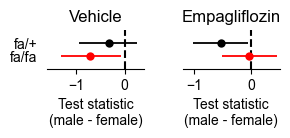

In [15]:
f, axes = plt.subplots(1, 2, figsize=(3, 0.5))
plt.subplots_adjust(wspace=0.4)

for ax, ts_, tle in zip(axes, (ts_vehicle, ts_change), ('Vehicle', 'Empagliflozin')):
    ax = forestplot_oz(ax, ts_);
    ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Test statistic\n(male - female)')
    
axes[0].set_xlim(-1.6,0.4)
axes[1].set_xlim(-1.2, 0.5)
axes[1].set_yticks([],[])
# f.savefig(PLOT_DIR / "ts_pow_CompareSexesForGtypAges.pdf", bbox_inches="tight")

## Show sign probabilities in tables

In [16]:
sp_all = pd.concat(objs=(sign_probabilities_change,
                sign_probabilities_gtyp,
                sign_probabilities_age, 
                sign_probabilities_sex), 
                   keys=('power',
                         'fa/fa - fa/+',
                         'young - adult', 
                         'male - female'), 
                   names=('contrast', 
                          'group'))
# sp_all.to_csv('../sp_tables/pow.csv')
sp_all

change change_signif  vehicle vehicle_signif
contrast      group                                                       
power         fa/fa adult M  0.00950             *      NaN            NaN
              fa/fa young M  0.01650             *      NaN            NaN
              fa/+ adult M   0.00000             *      NaN            NaN
              fa/+ young M   0.00000             *      NaN            NaN
              fa/fa adult F  0.00675             *      NaN            NaN
              fa/fa young F  0.02550                    NaN            NaN
              fa/+ adult F   0.00075             *      NaN            NaN
              fa/+ young F   0.00375             *      NaN            NaN
fa/fa - fa/+  M adult        0.98250             *  0.02725               
              M young        0.99325             *  0.21350               
              F adult        0.75225                0.11800               
              F young        0.80975                0.58200               
young - adult fa/fa          0.60475                0.53950               
              fa/+           0.41000                0.09275               
male - female fa/fa          0.43000                0.01150              *
              fa/+           0.01600             *  0.13600